[Previous: Module 5: Quantum Teleportation](05_Quantum_Teleportation.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 7: Grover's Search](07_Grovers_Search.ipynb)

# Module 6: Deutsch-Jozsa, the First Quantum Speed-up

**Learning objectives.** After this module you can:

* explain what an *oracle* is and build one as a circuit;
* explain **phase kickback**, the trick that turns a function evaluation into a sign;
* implement the Deutsch-Jozsa algorithm and show it answers with a single query where a classical computer may need many;
* adapt the same circuit to the Bernstein-Vazirani problem and read a hidden bit-string in one shot.

**Prerequisites.** [Module 4](04_Measurement_and_Interference.ipynb) (interference) and [Module 3](03_Multiple_Qubits_and_Entanglement.ipynb) (CNOT).

## 1. The problem

You are given a black-box function $f : \{0,1\}^n \to \{0,1\}$ and a promise: $f$ is either

* **constant** (the same output for every input), or
* **balanced** (output $0$ for exactly half the inputs and $1$ for the other half).

Decide which. Classically, in the worst case you must evaluate $f$ on $2^{n-1} + 1$ inputs: half of them could all say $0$ and the very next one says $1$.
Quantumly, **one** evaluation suffices, for any $n$.

Nobody needs to solve this particular problem. Its importance is that it was the first clean demonstration that interference can extract a *global*
property of a function (constant vs balanced) without looking at the values one by one. Grover and Shor use the same ingredients.

## 2. Oracles: functions as reversible circuits

A quantum computer can only apply unitaries, so we cannot "call" $f$; we embed it in a reversible gate $U_f$ acting on $n$ input qubits and one output qubit:

$$U_f\,|x\rangle|y\rangle = |x\rangle\,|y \oplus f(x)\rangle.$$

The input is left untouched and $f(x)$ is XORed into the output. Two easy families:

* **Constant:** do nothing ($f = 0$), or apply X to the output ($f = 1$).
* **Balanced:** CNOT from any non-empty set of input qubits into the output. $f(x)$ is then the parity of those bits, which is $1$ for exactly half of all inputs.
  Wrapping some inputs in X gates before and after gives more balanced functions.

A constant oracle (f = 1) and a balanced oracle:


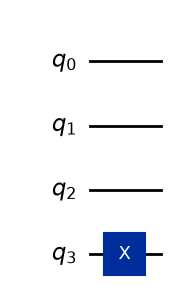

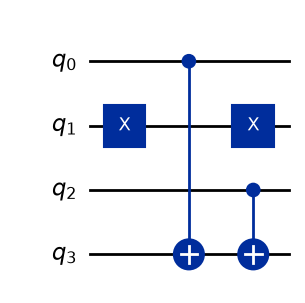

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def constant_oracle(n, value=0):
    qc = QuantumCircuit(n + 1, name=f"const f={value}")
    if value == 1:
        qc.x(n)                      # output qubit is qubit n
    return qc

def balanced_oracle(n, parity_qubits=None, flip_qubits=()):
    qc = QuantumCircuit(n + 1, name="balanced")
    parity_qubits = list(range(n)) if parity_qubits is None else parity_qubits
    for q in flip_qubits:  qc.x(q)   # optional relabelling of inputs
    for q in parity_qubits: qc.cx(q, n)
    for q in flip_qubits:  qc.x(q)
    return qc

n = 3
print("A constant oracle (f = 1) and a balanced oracle:")
display(constant_oracle(n, 1).draw('mpl'))
display(balanced_oracle(n, parity_qubits=[0, 2], flip_qubits=[1]).draw('mpl'))

In [2]:
# Check an oracle classically: feed each basis input, read the output qubit.
def truth_table(oracle, n):
    rows = []
    for i in range(2**n):
        x = format(i, f'0{n}b')                       # Qiskit order: rightmost char is qubit 0
        out = Statevector.from_label('0' + x).evolve(oracle)
        label = max(out.probabilities_dict(), key=out.probabilities_dict().get)
        rows.append((x, label[0]))                    # leftmost char is qubit n = output
    return rows

for name, oracle in [("constant f=1", constant_oracle(n, 1)), ("balanced", balanced_oracle(n, [0, 2], [1]))]:
    table = truth_table(oracle, n)
    ones = sum(int(fx) for _, fx in table)
    print(f"{name:<14} f(x) for x = 000..111: {[fx for _, fx in table]}   ({ones} ones out of {2**n})")

constant f=1   f(x) for x = 000..111: ['1', '1', '1', '1', '1', '1', '1', '1']   (8 ones out of 8)
balanced       f(x) for x = 000..111: ['0', '1', '0', '1', '1', '0', '1', '0']   (4 ones out of 8)


## 3. Phase kickback: turning a value into a sign

Prepare the output qubit in $|-\rangle = \tfrac{1}{\sqrt2}(|0\rangle - |1\rangle)$ instead of $|0\rangle$. XORing $f(x)$ into it does one of two things:

* $f(x) = 0$: $|-\rangle$ is untouched;
* $f(x) = 1$: $|0\rangle$ and $|1\rangle$ swap, and $|-\rangle$ becomes $-|-\rangle$.

So $U_f\,|x\rangle|-\rangle = (-1)^{f(x)}\,|x\rangle|-\rangle$. The output qubit never changes; instead the **sign** $(-1)^{f(x)}$ is *kicked back* onto the input.
If the input is in superposition, every branch $|x\rangle$ picks up its own sign at once. That is the "parallel evaluation" of quantum computing, and it is
useless until interference reads the pattern of signs out. Here it is with a single CNOT: the *control* is what changes.

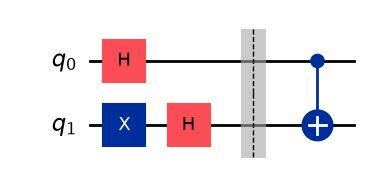

Before CNOT: control |+>, target |->


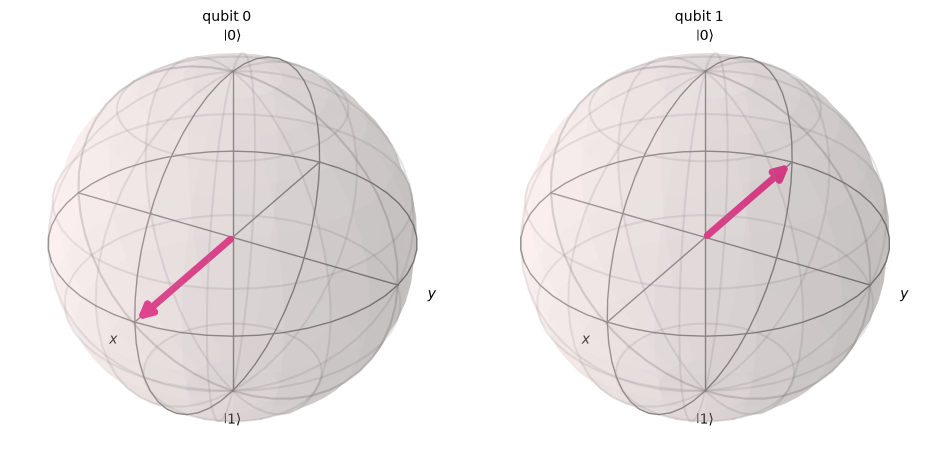

After CNOT:  the TARGET is unchanged, the CONTROL flipped from |+> to |->


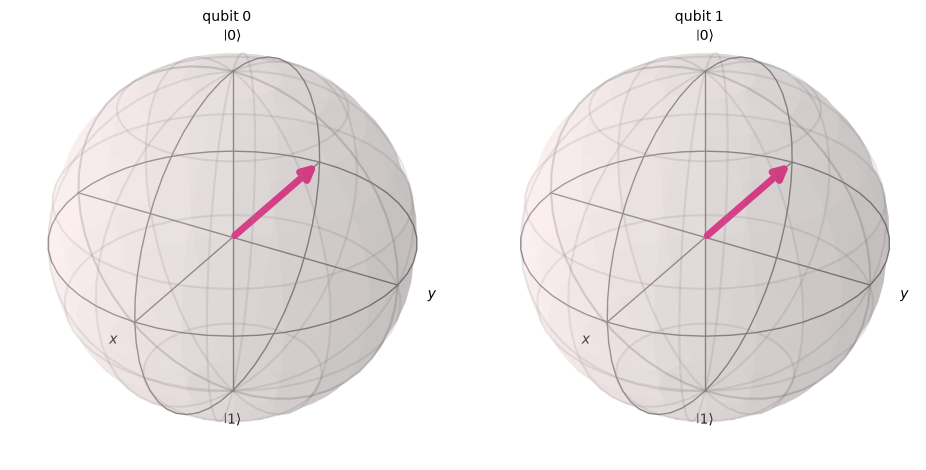

In [3]:
kick = QuantumCircuit(2)
kick.h(0)            # control: |+>
kick.x(1); kick.h(1) # target:  |->
before = Statevector(kick)
kick.barrier()
kick.cx(0, 1)
after = Statevector(kick)
display(kick.draw('mpl'))

print("Before CNOT: control |+>, target |->")
display(plot_bloch_multivector(before))
print("After CNOT:  the TARGET is unchanged, the CONTROL flipped from |+> to |->")
display(plot_bloch_multivector(after))

## 4. The algorithm

1. Start with $|0\rangle^{\otimes n}|1\rangle$; apply H to every qubit. The inputs become the uniform superposition $\tfrac{1}{\sqrt{2^n}}\sum_x |x\rangle$ and the output becomes $|-\rangle$.
2. Apply $U_f$ once. Phase kickback gives $\tfrac{1}{\sqrt{2^n}}\sum_x (-1)^{f(x)}|x\rangle\,|-\rangle$.
3. Apply H to the $n$ input qubits and measure them.

The amplitude of the all-zeros outcome after the final H is the *average* of the signs:

$$a_{0\cdots0} = \frac{1}{2^n}\sum_x (-1)^{f(x)} = \begin{cases} \pm 1 & f \text{ constant} \\ 0 & f \text{ balanced.} \end{cases}$$

Constant: the signs all agree, interfere constructively, and you measure $0\cdots0$ with certainty. Balanced: half the signs are $+$ and half $-$; they cancel exactly,
and $0\cdots0$ is *impossible*. One query, one measurement, a definite answer.

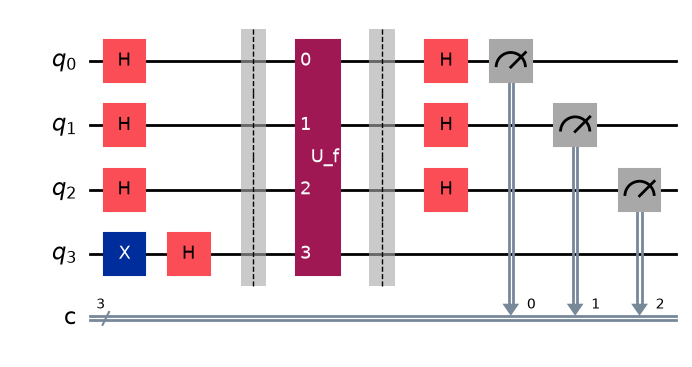

constant f=0                       -> CONSTANT  {'000': 1000}
constant f=1                       -> CONSTANT  {'000': 1000}
balanced (parity of all)           -> BALANCED  {'111': 1000}
balanced (q0 xor q2, q1 flipped)   -> BALANCED  {'101': 1000}


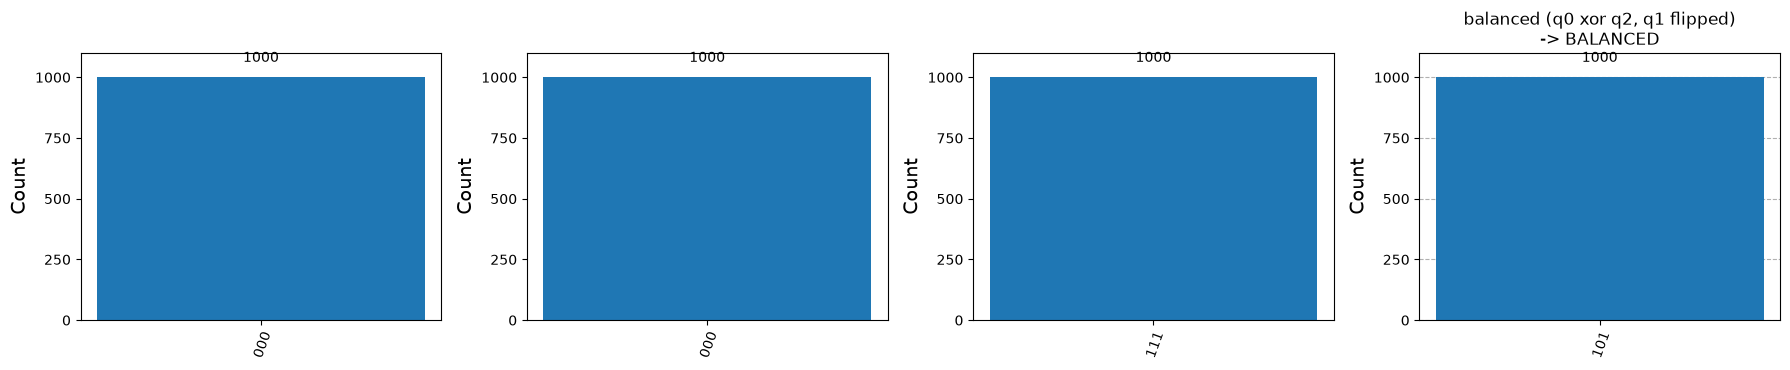

In [4]:
def deutsch_jozsa(oracle, n):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)                       # output qubit -> |1>
    qc.h(range(n + 1))            # inputs -> uniform superposition, output -> |->
    qc.barrier()
    qc.append(oracle.to_gate(label="U_f"), range(n + 1))
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

def classify(counts):
    return "CONSTANT" if set(counts) == {'0' * n} else "BALANCED"

qc = deutsch_jozsa(balanced_oracle(n, [0, 2], [1]), n)
display(qc.draw('mpl'))

oracles = {
    "constant f=0": constant_oracle(n, 0),
    "constant f=1": constant_oracle(n, 1),
    "balanced (parity of all)": balanced_oracle(n),
    "balanced (q0 xor q2, q1 flipped)": balanced_oracle(n, [0, 2], [1]),
}
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (name, oracle) in zip(axes, oracles.items()):
    counts = simulator.run(transpile(deutsch_jozsa(oracle, n), simulator), shots=1000).result().get_counts()
    verdict = classify(counts)
    print(f"{name:<34} -> {verdict:<9} {counts}")
    plot_histogram(counts, ax=ax, title=f"{name}\n-> {verdict}")
plt.tight_layout(); plt.show()

> **What to notice.** The constant oracles give `000` in every one of 1000 shots. The balanced oracles *never* give `000`.
> A single run of the circuit, even a single shot, settles the question. The classical worst case for $n=3$ is 5 evaluations.

## 5. Watching the amplitudes (Deutsch's algorithm, $n = 1$)

With one input qubit the whole state has four amplitudes and we can watch every step. Compare a constant oracle (identity) with a balanced one (CNOT).
Labels are $|q_1 q_0\rangle$ with $q_1$ the output qubit. Look only at the sign pattern: after the oracle, the balanced case has *mixed* signs on the input.

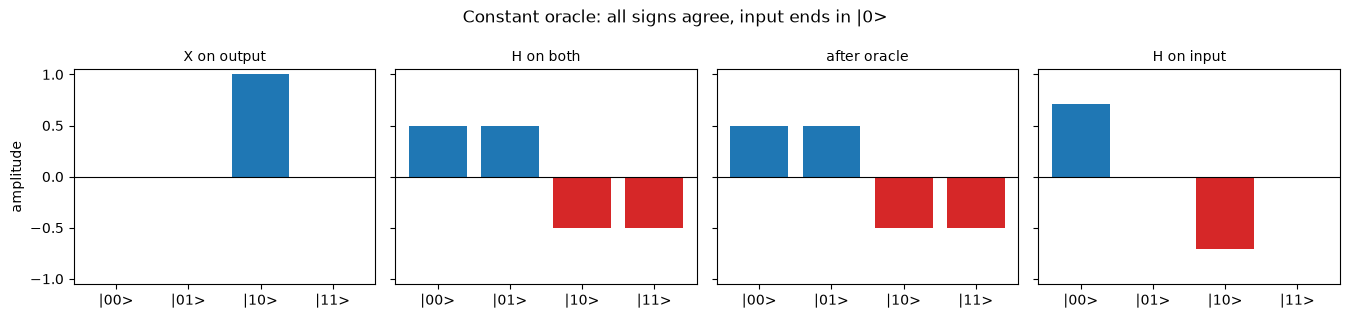

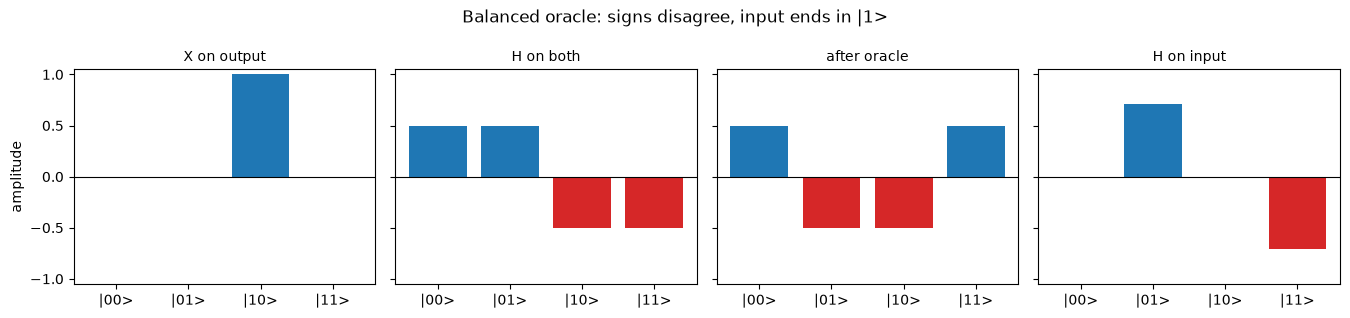

In [5]:
def amplitude_bars(states, titles, suptitle):
    fig, axes = plt.subplots(1, len(states), figsize=(3.4*len(states), 3.2), sharey=True)
    for ax, sv, t in zip(axes, states, titles):
        amps = sv.data.real
        labels = [f"|{format(i, f'0{sv.num_qubits}b')}>" for i in range(len(amps))]
        ax.bar(labels, amps, color=['tab:blue' if a >= 0 else 'tab:red' for a in amps])
        ax.axhline(0, color='k', lw=0.8); ax.set_ylim(-1.05, 1.05); ax.set_title(t, fontsize=10)
    axes[0].set_ylabel('amplitude'); fig.suptitle(suptitle); plt.tight_layout(); plt.show()

def steps(oracle):
    qc = QuantumCircuit(2)
    states, titles = [], []
    qc.x(1);                      states.append(Statevector(qc)); titles.append("X on output")
    qc.h([0, 1]);                 states.append(Statevector(qc)); titles.append("H on both")
    qc.compose(oracle, inplace=True); states.append(Statevector(qc)); titles.append("after oracle")
    qc.h(0);                      states.append(Statevector(qc)); titles.append("H on input")
    return states, titles

amplitude_bars(*steps(constant_oracle(1, 0)), "Constant oracle: all signs agree, input ends in |0>")
amplitude_bars(*steps(balanced_oracle(1)),   "Balanced oracle: signs disagree, input ends in |1>")

## 6. Bernstein-Vazirani: reading a hidden string in one query

Change the promise. Now $f(x) = s \cdot x \bmod 2$ for some secret $n$-bit string $s$, and the task is to find $s$.
Classically you need $n$ queries (one per bit). The Deutsch-Jozsa circuit, unchanged, returns $s$ itself in one query:
after the final H the state is exactly $|s\rangle$.

The oracle is just CNOTs from the input qubits where $s$ has a $1$ into the output.

secret string : 101101
measured      : {'101101': 1000}


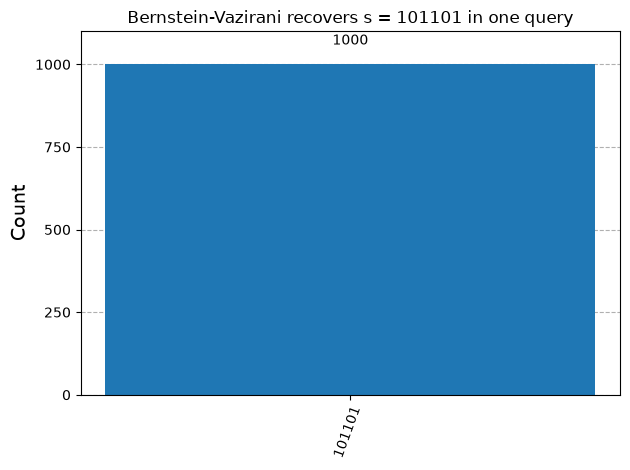

In [6]:
def bv_oracle(secret):
    n = len(secret)
    qc = QuantumCircuit(n + 1, name="BV")
    for i, bit in enumerate(reversed(secret)):    # reversed: rightmost char of the string is qubit 0
        if bit == '1':
            qc.cx(i, n)
    return qc

secret = '101101'
n_bv = len(secret)
qc = deutsch_jozsa(bv_oracle(secret), n_bv)
counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()

print(f"secret string : {secret}")
print(f"measured      : {counts}")
plot_histogram(counts, title=f"Bernstein-Vazirani recovers s = {secret} in one query")

## Try it yourself

**Exercise 1.** Write `random_oracle(n)` that secretly picks constant or balanced. Classify it with the algorithm, then reveal the truth.

**Exercise 2.** Run Deutsch-Jozsa for $n = 6$. How many classical evaluations would the worst case need?

**Exercise 3.** Use the formula in section 4 to explain why a *non*-balanced, non-constant function (say $f=1$ on 3 of 8 inputs) gives `000` with probability $(1/4)^2 = 1/16$. Build such an oracle and check the histogram.

**Exercise 4 (challenge).** Bernstein-Vazirani with an 8-bit secret and 1 shot. Does it still work? Why?

<details><summary>Solutions</summary>

```python
# Exercise 1
def random_oracle(n):
    rng = np.random.default_rng()
    if rng.random() < 0.5:
        return constant_oracle(n, int(rng.integers(2))), "constant"
    k = int(rng.integers(1, n + 1))
    return balanced_oracle(n, list(rng.choice(n, k, replace=False))), "balanced"
oracle, truth = random_oracle(3)
counts = simulator.run(transpile(deutsch_jozsa(oracle, 3), simulator), shots=100).result().get_counts()
print("algorithm says", classify(counts), "| truth:", truth)

# Exercise 2: 2^(6-1) + 1 = 33 evaluations classically, 1 quantumly.

# Exercise 3: f = 1 on inputs 000, 001, 010 (3 of 8): average sign = (5 - 3)/8 = 1/4, P(000) = 1/16
# An oracle for that: flip output when q2 == 0 and (q1, q0) != (1, 1)  ->  build with a Toffoli, or use qc.initialize on a custom Statevector.

# Exercise 4: yes. The final state is exactly |s>, so even ONE shot returns s with certainty.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from qclab import quiz

quiz(6)

## Key takeaways

* An oracle embeds a classical function in a reversible gate $|x\rangle|y\rangle \to |x\rangle|y \oplus f(x)\rangle$.
* Phase kickback with the output in $|-\rangle$ writes $(-1)^{f(x)}$ onto each input branch in a single call.
* Deutsch-Jozsa: H, oracle, H. Constant functions interfere constructively into $0\cdots0$; balanced functions cancel it to zero.
* The same circuit solves Bernstein-Vazirani, returning the hidden string directly.

**Next:** amplify the right answer step by step. [Module 7](07_Grovers_Search.ipynb).

[Previous: Module 5: Quantum Teleportation](05_Quantum_Teleportation.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 7: Grover's Search](07_Grovers_Search.ipynb)